# 核心思想

PPO 解决的是传统策略梯度方法中 策略更新步长难以控制 的问题。如果更新步长太大，策略可能突然变差且难以恢复；步长太小则训练效率低。

PPO 通过 限制新旧策略之间的差异 ，在保证训练稳定性的同时实现高效学习。

# 原始策略梯度（REINFORCE）

策略梯度定理给出的梯度方向为
$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \cdot R(\tau) \right]$$


- $\nabla_\theta J(\theta)$：目标函数 J(θ) （期望累积回报）对策略参数 θ 的 梯度 。我们沿着这个方向更新参数来提升策略
- $\mathbb{E}_{\tau \sim \pi_\theta}$：对轨迹 $\tau$ 求 期望 。轨迹 $\tau = (s_0,a_0,r_0, s_1,a_1,r_1, \ldots)$ 是从当前策略 $\pi_\theta$ 采样出来的
- $\nabla_\theta \log \pi_\theta(a_t|s_t)$：得分函数。要增大"在状态 $s_t$ 下选择动作 $a_t$ 的概率"，参数 $\theta$ 应该向哪个方向移动（**往哪个方向调**）
- $R(\tau)$：整条轨迹的 总回报 ，作为该轨迹的"权重"。回报高的轨迹中的动作被加强，回报低的被减弱（**调多大力度**）


**原始策略梯度的核心缺陷：**

- **高方差**：$R(\tau)$ 作为权重，波动极大。同样的好动作，出现在不同的轨迹里，权重可能差几十倍。
>例子 ：两局游戏的开头都选了"向左走"：
>- 轨迹 A：后续运气好，最终得分 100 → 大力加强"向左走"
>- 轨迹 B：后续失误了，最终得分 5 → 几乎不加强"向左走"
>
>→ 同一个动作，梯度信号天差地别，训练极不稳定。

- **样本效率极低**：每采一批数据 → 更新一次 → 数据必须丢弃，因为梯度公式要求轨迹必须从当前策略 $π_θ$ 采样。大部分数据只用一次就扔了，很浪费。

- **步长敏感，容易训崩**：没有机制限制策略更新的幅度。
>一次参数更新后，策略可能突变，导致：
>- 新策略采出来的数据质量断崖式下降
>- 一旦掉进"差策略"区域，很难爬回来（因为差策略采不出好数据来纠正自己）


**从 REINFORCE 到 PPO：**
```
REINFORCE (R(τ) 做权重)
   ↓  引入 baseline 降方差
R(τ) - b  →  仍不够稳定
   ↓  引入 Actor-Critic，用优势函数 A(s,a)
A2C / A3C  →  稳定了，但仍是 on-policy，样本效率低
   ↓  引入重要性采样，想复用旧数据
TRPO  →  能复用数据了，但需要二阶优化（共轭梯度），实现复杂
   ↓  用 clip 替代 KL 约束，一阶就够了
PPO  →  简单、稳定、效果好的最终方案 ✅
```

# 近端策略优化（PPO）

## PPO 解决了什么问题

| 旧方法的问题 | 为什么麻烦 | PPO 的解决思路 |
|------------|-----------|---------------|
| 策略梯度样本利用率低 | 每次更新都重新采样，LLM 生成轨迹成本很高 | 用重要性采样复用旧策略生成的数据 |
| 策略更新步长不可控 | 一次大更新可能导致策略崩溃 | 用 Clip 裁剪限制新旧策略概率比 |
| TRPO 太重 | KL 约束和二阶优化实现复杂、训练成本高 | 用一阶优化 + 裁剪目标函数近似信任区域 |


PPO 通过两个关键机制实现这一目标：

- 重要性采样：允许用“旧策略”采集的数据来训练“当前策略”（数据复用）
- Clip 裁剪：限制策略更新的步长，防止策略崩溃

**On-policy or Off-policy？**

PPO 是一种 On-policy 算法。

**判断标准：用来更新网络的数据，是不是由当前这一轮最新策略产生的。**

- 纯粹的 On-policy 算法，比如 REINFORCE 或 A2C，通常要先用当前策略去环境里跑一批轨迹，拿到数据后更新一次参数，然后把这批旧数据扔掉。参数一变，策略就变了；下一次更新必须重新采样。这种方式稳定，但样本利用率低。

- 纯粹的 Off-policy 算法，比如 DQN、SAC、TD3，则会维护一个很大的经验回放池（Replay Buffer）。过去几天、几周，甚至更久以前采集的数据，都可以反复拿出来训练当前网络。它们不要求训练数据一定来自当前最新策略。


## 重要性采样
在策略梯度中，我们需要从当前策略 $\pi_{\theta}$ 中采样轨迹来计算梯度。但如果每次更新参数后都重新采样，效率极低。重要性采样允许我们用旧策略 $\pi_{\theta_{\text{old}}}$ 的样本来估计新策略 $\pi_{\theta}$ 的梯度。


重要性采样比率：
$$\rho_t = \frac{\pi_{\theta_{\text{old}}}(a_t|s_t)}{\pi_\theta(a_t|s_t)}$$

- $\rho_t = 1$：当前策略与旧策略对这个动作的偏好完全一致
- $\rho_t > 1$：当前策略比旧策略更倾向于这个动作（即"当前策略认为这个动作更好了"）
- $\rho_t < 1$：当前策略比旧策略更不倾向于这个动作（"当前策略认为这个动作变差了"）
- $\rho_t = 2$：当前策略选择该动作的概率是旧策略的 2 倍

重要性采样的直觉：假设旧策略采样到某个动作的概率是 $10\%$（$\pi_{\text{old}} = 0.1$），而当前策略认为该动作概率应该是 $30\%$（$\pi_\theta = 0.3$），则 $\rho = 3$。这意味着如果用旧策略的数据来估计新策略的期望，每条这样的数据应该被赋予 $3$ 倍权重——因为新策略"本应"更频繁地采到它。


## 优势函数

策略梯度中，用累积奖励 R(τ) 作为权重会导致高方差。优势函数（Advantage Function） 通过引入一个基准线来解决这个问题：
$$A_t = Q(s_t, a_t) - V(s_t)$$


- $Q(s_t, a_t)$：在状态 $s_t$ 下执行动作 $a_t$ 后，能获得的期望累积奖励（动作价值）
- $V(s_t)$：在状态 $s_t$ 下，按当前策略执行所能获得的期望累积奖励（状态价值，即"基准线"）
- $A_t > 0$：动作 $a_t$ 比"平均水平"好 → 应当强化
- $A_t < 0$：动作 $a_t$ 比"平均水平"差 → 应当抑制
- $A_t = 0$：动作 $a_t$ 与平均水平持平 → 无需调整

把绝对分数转为相对分数，消除了分数尺度的干扰，让信号更加稳定。

## 广义优势估计（GAE）：计算优势函数

对于优势函数：
$$A_t = Q(s_t, a_t) - V(s_t)$$
其中 $V(s_t)$ 难以精确估计。

**TD 误差：**
$$\delta_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t)$$

- $V_\phi(s_t)$：Critic 原来预测，从当前状态 $s_t$ 往后走，未来总价值大约是多少。
- $r_t + \gamma V_\phi(s_{t+1})$：实际采取动作后，我们马上拿到了奖励 $r_t$，并且到达了下一状态 $s_{t+1}$；Critic 再估计下一状态的未来价值，然后乘以折扣因子 $\gamma$。

两者相减，就是"现实比预期好多少"。
- $\delta_t > 0$：实际结果比 Critic 预期更好，这是正向惊喜，说明刚才这个动作可能值得强化。
- $\delta_t < 0$：实际结果比 Critic 预期更差，这是负向惊喜，说明刚才这个动作可能应该被抑制。
- $\delta_t \approx 0$：结果基本符合预期，说明这一步没有提供太多新的学习信号。


GAE 的做法是：不只看当前步的 TD 误差 $\delta_t$，还看后面几步的 TD 误差 $\delta_{t+1}, \delta_{t+2}, \ldots$，但越远的步骤权重越小：

$$A_t^{\text{GAE}} = \delta_t + (\gamma\lambda)\delta_{t+1} + (\gamma\lambda)^2 \delta_{t+2} + \cdots$$

写成求和形式就是：

$$A_t^{\text{GAE}} = \sum_{l=0}^{T-t} (\gamma\lambda)^l \delta_{t+l}$$

这里的关键是 $(\gamma\lambda)^l$：

- $l=0$：当前步，权重是 $1$。
- $l=1$：下一步，权重是 $\gamma\lambda$。
- $l=2$：再下一步，权重是 $(\gamma\lambda)^2$。

由于折扣因子 $\gamma$ 的存在，越往后，权重指数衰减，对当前动作的影响越小。

$\lambda \in [0,1]$ 是 GAE 折衷参数。它决定我们到底更相信"近处的一步 TD 估计"，还是更愿意看完整轨迹。
| λ 值 | GAE 退化为 | 偏差 | 方差 | 直觉 |
|:---:|:---|:---|:---|:---|
| λ=0 | 单步 TD：$A_t = \delta_t$ | 高（完全依赖 Critic 精度） | 低 | 只看一步的"惊喜"，很稳但短视 |
| λ=1 | 蒙特卡洛：$A_t = \sum_{l} \gamma^l \delta_{t+l}$ | 低（用完整轨迹） | 高 | 看完整轨迹，信息全但波动大 |
| λ=0.95 | PPO 常用值 | 适中 | 适中 | 既看近期，也保留一部分远期影响 |


```
Critic 网络
    │
    ▼
对于每个 s_t，输出 V(s_t), V(s_{t+1}), V(s_{t+2}), ...
    │                              │
    ▼                              ▼
GAE 用这些 V 值计算 TD 误差         Actor 用 A_t^GAE 更新策略
δ_t = r_t + γ·V(s_{t+1}) - V(s_t)
    │
    ▼
GAE 加权求和 → A_t^GAE
    │
    ├──→ 送给 Actor 做策略更新
    │
    └──→ 同时算出回报 R_t，用来训练 Critic 自身（MSE loss）
```

## PPO Clip：限制新旧策略差异

**在新旧策略差异过大时，直接截断梯度，不让参数继续往那个方向走。**

$$L^{PPO}(\theta) = -\mathbb{E}_t \left[ \min\left( \rho_t A_t, \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon) A_t \right) \right]$$


- $\rho_t$ ：重要性采样比率，$\rho_t = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}$
- $A_t$ ：优势函数（GAE 算出来的）
    - $A_t > 0$（好动作，该加强）
    - $A_t < 0$（差动作，该减弱）
- $\varepsilon$ ：裁剪范围，通常 $0.2$，即允许 $\rho_t$ 在 $[0.8, 1.2]$ 内自由变化
- $\mathbb{E}_t$ ：期望，对时间步 $t$ 进行期望，等价于对一批采样数据求平均。
- 前面的负号 ：框架做 梯度下降 最小化 Loss，所以加负号把"最大化回报"变成"最小化损失"

## KL 散度：限制与初始策略的差异

Clip 机制限制的是单个动作的概率变化幅度，但它无法约束策略整体分布的漂移。

在 RLHF 场景中，如果模型为了追求高奖励而"忘记"了 **SFT 阶段** 学到的通用语言能力（如语法、连贯性），就会出现语言退化或奖励黑客（reward hacking）——模型找到某种"讨巧"的输出模式来骗取高奖励，但人类读起来一塌糊涂。

KL 散度定义为：

$$D_{\text{KL}}(\pi_\theta \parallel \pi_{\text{ref}}) = \mathbb{E}_{y \sim \pi_\theta} \left[ \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)} \right]$$

- $\pi_{\text{ref}}$：参考策略（Reference Policy），RL 训练开始前的 SFT 模型快照
- $D_{\text{KL}}(\pi_\theta \parallel \pi_{\text{ref}})$：衡量当前策略 $\pi_\theta$ 相对于参考策略 $\pi_{\text{ref}}$ 的分布偏离程度。$D_{\text{KL}}=0$ 表示两者完全一致；$D_{\text{KL}}$ 越大，偏离越严重  
- 最后整个 KL 散度表达式 × $\beta$：KL 惩罚系数——控制"探索新策略"与"保持原有能力"之间的平衡


$$\log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)}$$

- 如果两个模型对某个回答的概率一样 → log(1) = 0 → KL = 0，没偏离
- 如果当前模型认为概率高、参考模型认为概率低 → 比值 > 1 → log > 0 → KL 为正，有偏离

## PPO 完整优化目标

完整优化目标：
$$L_{\text{PPO-RLHF}}(\theta) = -\mathbb{E}_t\left[\min\left(\rho_t A_t, \text{clip}(\rho_t, 1-\epsilon, 1+\epsilon)A_t\right)\right] + \beta \cdot D_{\text{KL}}(\pi_\theta \parallel \pi_{\text{ref}})$$

其中：

重要性采样比率：
$$\rho_t = \frac{\pi_{\theta_{\text{old}}}(a_t|s_t)}{\pi_\theta(a_t|s_t)}$$

优势函数：
$$A_t = Q(s_t, a_t) - V(s_t)$$

KL 散度：
$$D_{\text{KL}}(\pi_\theta \parallel \pi_{\text{ref}}) = \mathbb{E}_{y \sim \pi_\theta} \left[ \log \frac{\pi_\theta(y \mid x)}{\pi_{\text{ref}}(y \mid x)} \right]$$

## PPO 缺点

1. 本质 On-policy

虽然通过重要性采样可以多用几轮（通常 3~4 个 epoch），但本质上仍是 on-policy 方法

2. Clip 在长期尺度上无法保证不跑偏

Clip 只能防止"单步更新过大"，但不能防止"多轮累积跑偏"：

3. 显存压力

需同时维护 Actor 和 Critic 模型，显存压力较大。

# 补充

**PPO 既然有了固定的优化目标函数，还能设置奖励函数吗？**

>可以，而且必须设置。两者是不同层面的东西。
```
你定义的奖励函数
       │
       ▼
环境给出 r_t（每步的即时奖励）
       │
       ▼
Critic 估计 V(s_t)，GAE 算出 A_t
       │
       ▼
PPO Clip：min(ρ_t·A_t, clip(ρ_t)·A_t)  ← 这里 PPO 登场
       │
       ▼
更新 Actor 和 Critic 的参数
```

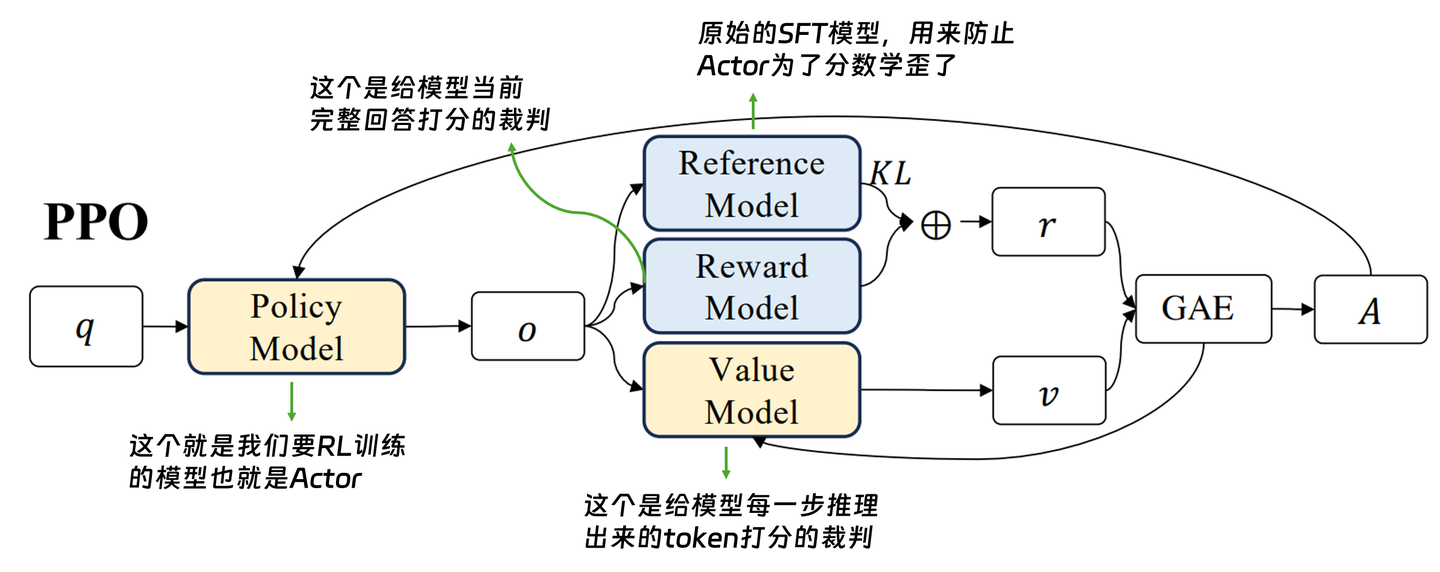

PPO 需要维护 4 个模型：

| 模型 | 参数状态 | 角色 | 任务/说明 |
|:---|:---|:---|:---|
| **I. Actor** | 需更新参数 | 主角 | 正在训练的模型，负责根据问题生成回答 |
| **II. Reference Model<br>参考模型** | 冻结参数 | SFT 后的原始模型副本 | 作为约束，计算 KL 散度，防止 Actor 偏离太远 |
| **III. Reward Model<br>奖励模型** | 冻结参数 | 代表人类偏好的判卷人 | 等 Actor 生成完整回答后给出最终分数（如 8.0 分）<br>通常基于 SFT 模型改造（如 Llama-3-8B-Instruct、Qwen3-14B-Instruct） |
| **IV. Critic<br>评判模型** | 更新参数 | 实时评估者 | 与 Actor 同款架构（如 7B），输出维度 `[Batch_Size, Seq_Len, 1]`<br>为 Actor 的**每个 token** 提供即时评分 |


显存驻留情况（假设模型大小为 70B）：

| 模型 | 大小 | 是否必须常驻显存 | 说明 |
|------|------|------------------|------|
| Actor（π_θ） | 70B | 是 | 需要前向+反向，必须有梯度 |
| Critic（V） | 70B | 共享 | 通常和 Actor 共享底层权重，额外只有一个 value head |
| Ref Model（π_ref） | 70B | 否 | 冻结参数，只需前向，可以 offload 到 CPU |
| Reward Model（r_φ） | 通常远小于 70B | 是 | 实际中 300M~7B 就够了，不需要 70B |


# Reference

[1] [PPO：近端策略优化](https://haozhe-xing.github.io/agent_learning/zh/chapter_agentic_rl/03_ppo.html) <br>
[2] [看完能和外婆解释的PPO, DPO, GRPO强化学习](https://zhuanlan.zhihu.com/p/1984387073625593089) <br>